# EDA Telco Customer Churn
**Proyecto:** Predicción de Abandono de Clientes con ML + LLM  

## Configuración e importaciones

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Estilo uniforme para todas las figuras
plt.rcParams.update({
    'figure.dpi': 200,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

# Paleta de colores: azul = no abandona, rojo = abandona
PALETTE = {'No': '#4C9BE8', 'Yes': '#E85C5C'}

# Ruta donde se guardan las figuras
FIG_DIR = '../data/figures/'
os.makedirs(FIG_DIR, exist_ok=True)

print('Configuración lista. Carpeta de figuras creada en:', os.path.abspath(FIG_DIR))

Configuración lista. Carpeta de figuras creada en: c:\Users\Lenovo\Downloads\Churn-Prediction-LLM\data\figures


## Carga y revisión inicial del dataset

In [4]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# TotalCharges viene como texto con espacios en blanco en algunos registros
# Se convierte a numérico; los valores no convertibles quedan como NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
print(f'Variables numéricas: {df.select_dtypes(include=np.number).columns.tolist()}')
print(f'Variables categóricas: {df.select_dtypes(include=object).columns.tolist()}')
df.head()

Filas: 7043 | Columnas: 21
Variables numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Variables categóricas: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Análisis de valores nulos y estrategia de manejo

In [5]:
nulos = df.isnull().sum()
print('Valores nulos por columna:')
print(nulos[nulos > 0])

# Los nulos en TotalCharges corresponden a clientes con tenure = 0
# Es decir, clientes nuevos que aún no tienen historial de facturación
tenure_de_nulos = df[df['TotalCharges'].isna()]['tenure'].unique()
print(f'\nTenure de filas con TotalCharges nulo: {tenure_de_nulos}')
print('Estrategia: imputar con 0 porque no hay cargo acumulado para clientes nuevos.')

df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(f'Nulos restantes: {df.isnull().sum().sum()}')

Valores nulos por columna:
TotalCharges    11
dtype: int64

Tenure de filas con TotalCharges nulo: [0]
Estrategia: imputar con 0 porque no hay cargo acumulado para clientes nuevos.
Nulos restantes: 0


In [6]:
# Estadísticas descriptivas de las variables numéricas
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


## Figura 1: Distribución del target (Churn)

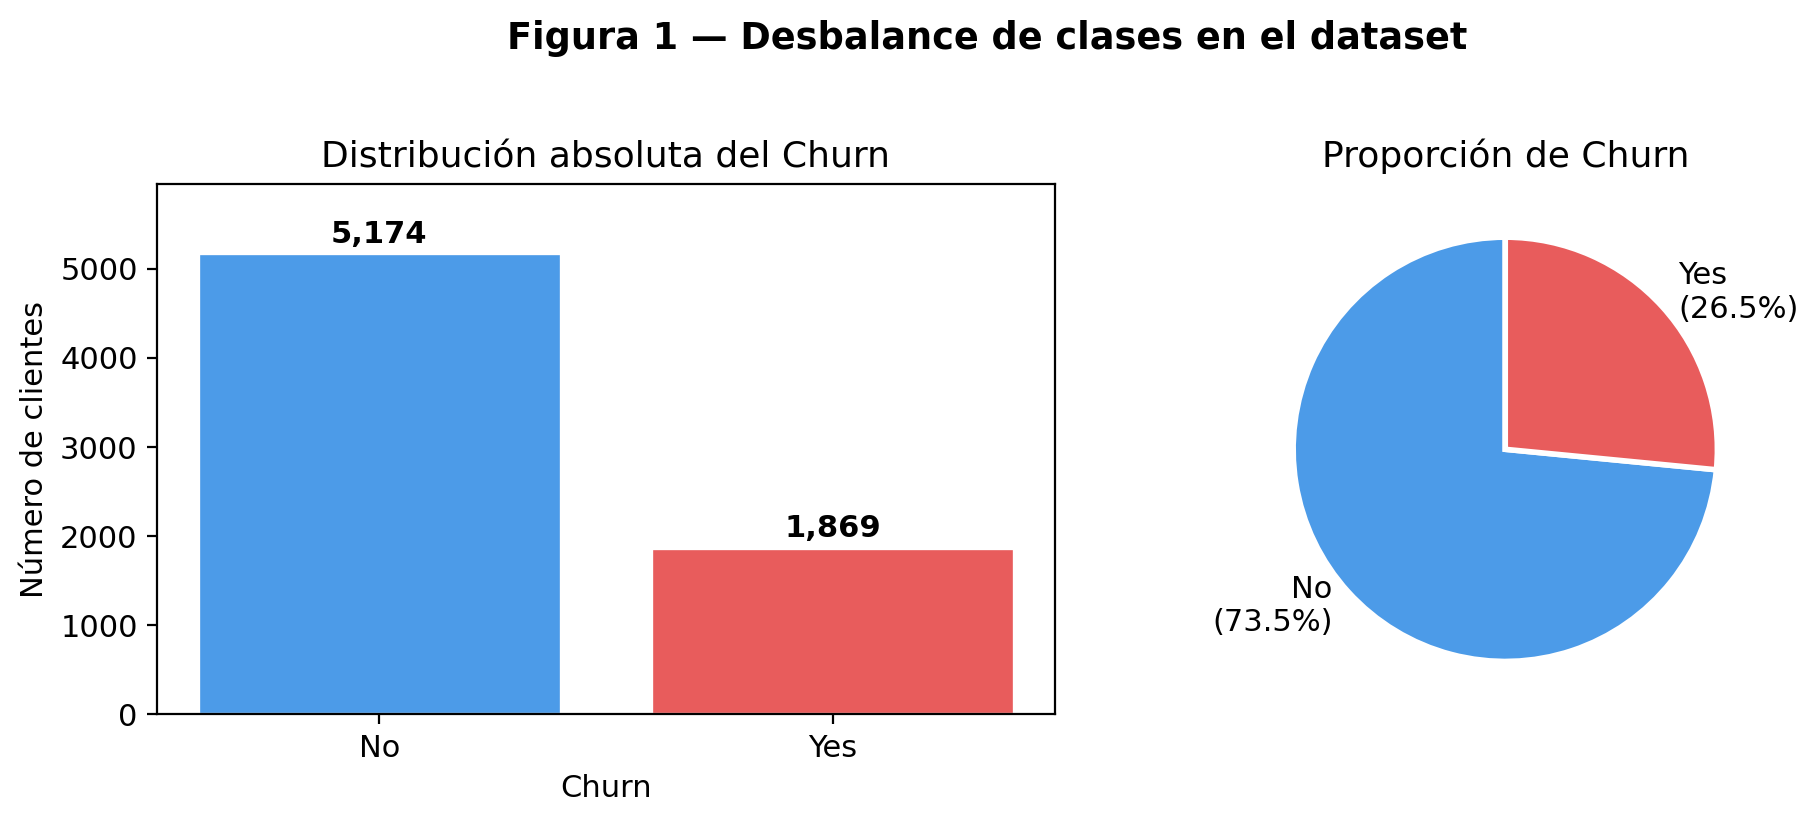

Desbalance: 26.5% Churn vs 73.5% No-Churn
Decisión tomada: usar AUC-ROC y F1 como métricas principales, no Accuracy.


In [7]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfica de barras con conteo absoluto
bars = axes[0].bar(
    churn_counts.index,
    churn_counts.values,
    color=[PALETTE[k] for k in churn_counts.index],
    edgecolor='white',
    linewidth=1.2
)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{val:,}',
        ha='center', va='bottom', fontweight='bold'
    )
axes[0].set_title('Distribución absoluta del Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Número de clientes')
axes[0].set_ylim(0, churn_counts.max() * 1.15)

# Gráfica de torta con porcentajes
axes[1].pie(
    churn_counts.values,
    labels=[f'{k}\n({v:.1f}%)' for k, v in zip(churn_pct.index, churn_pct.values)],
    colors=[PALETTE[k] for k in churn_counts.index],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporción de Churn')

plt.suptitle('Figura 1 — Desbalance de clases en el dataset', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig1_churn_distribution.png')
plt.show()

print(f'Desbalance: {churn_pct["Yes"]:.1f}% Churn vs {churn_pct["No"]:.1f}% No-Churn')
print('Decisión tomada: usar AUC-ROC y F1 como métricas principales, no Accuracy.')

## Figura 2: Variables numéricas por grupo de Churn

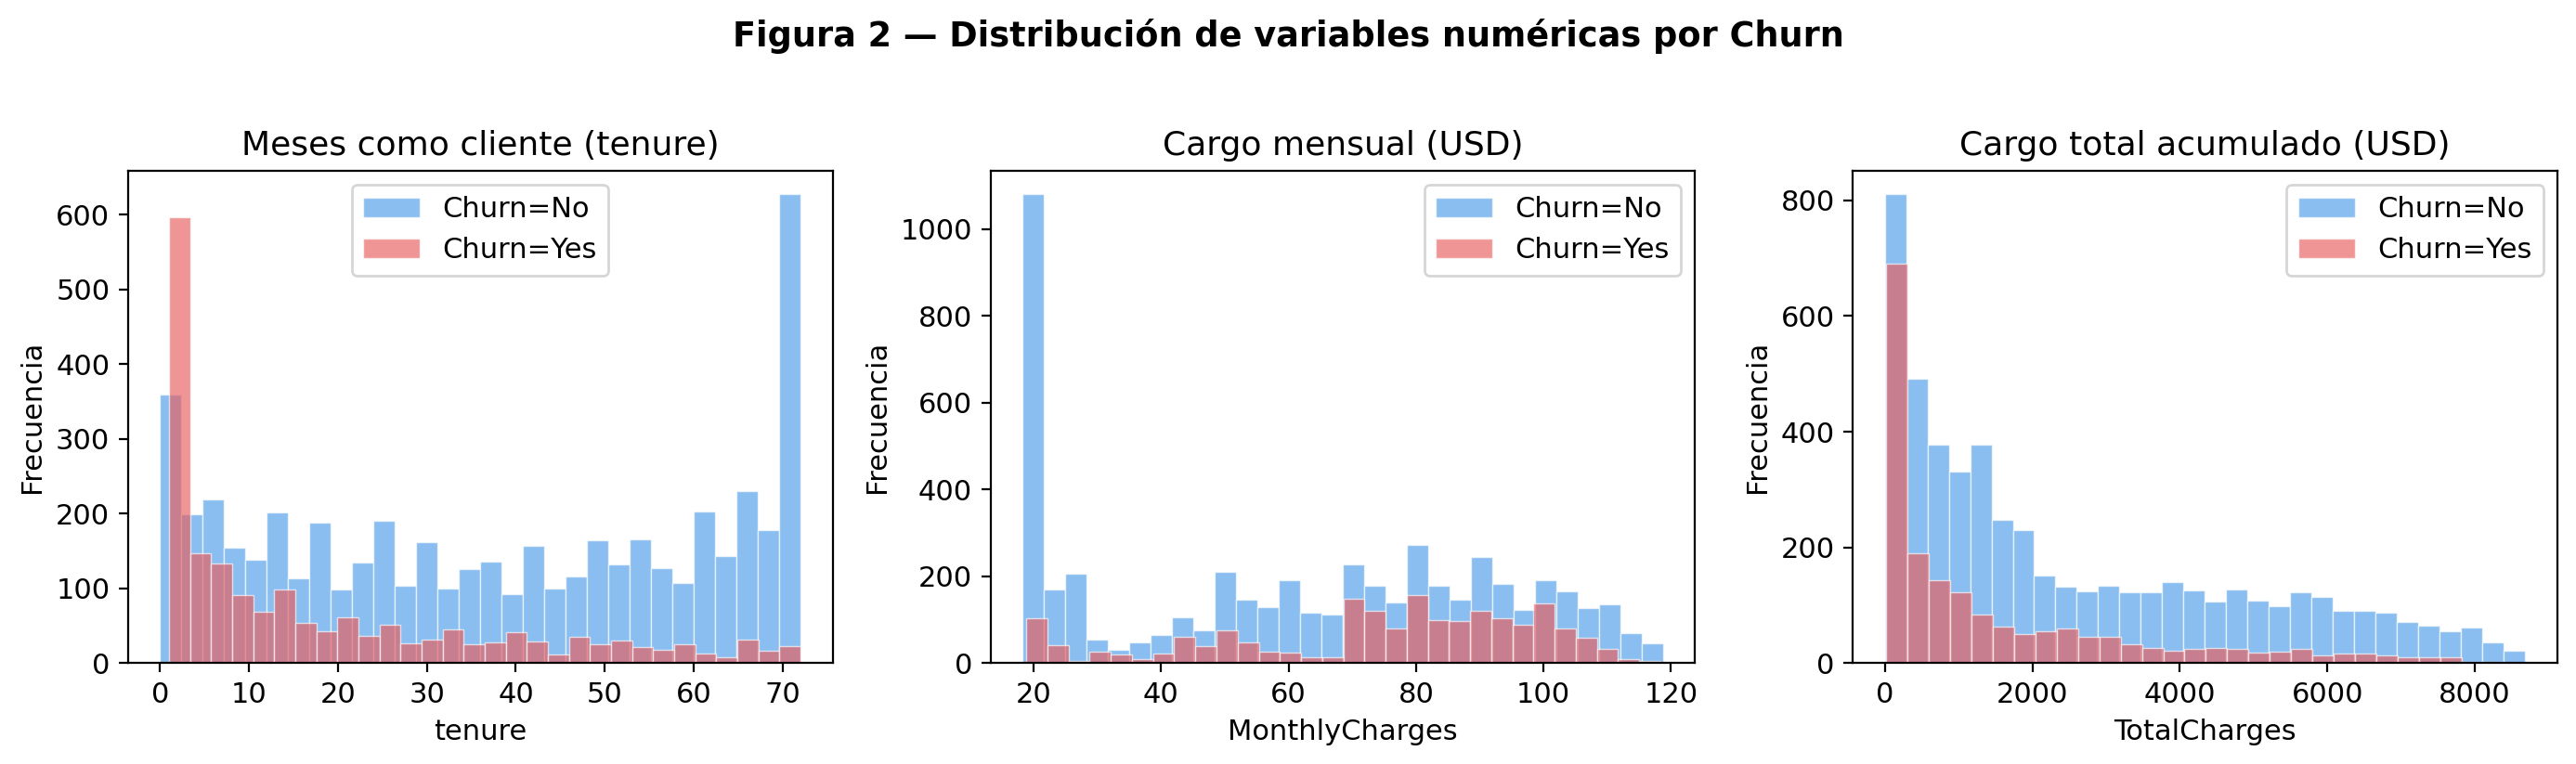

Media por grupo:


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2549.91
Yes,17.98,74.44,1531.80


In [8]:
num_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']
labels   = ['Meses como cliente (tenure)', 'Cargo mensual (USD)', 'Cargo total acumulado (USD)']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, var, label in zip(axes, num_vars, labels):
    for churn_val, color in PALETTE.items():
        datos = df[df['Churn'] == churn_val][var]
        ax.hist(
            datos, bins=30, alpha=0.65,
            color=color, label=f'Churn={churn_val}',
            edgecolor='white', linewidth=0.5
        )
    ax.set_title(label)
    ax.set_xlabel(var)
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.suptitle('Figura 2 — Distribución de variables numéricas por Churn', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig2_numeric_distributions.png')
plt.show()

print('Media por grupo:')
df.groupby('Churn')[num_vars].mean().round(2)

## Figura 3: Tasa de Churn por variables categóricas

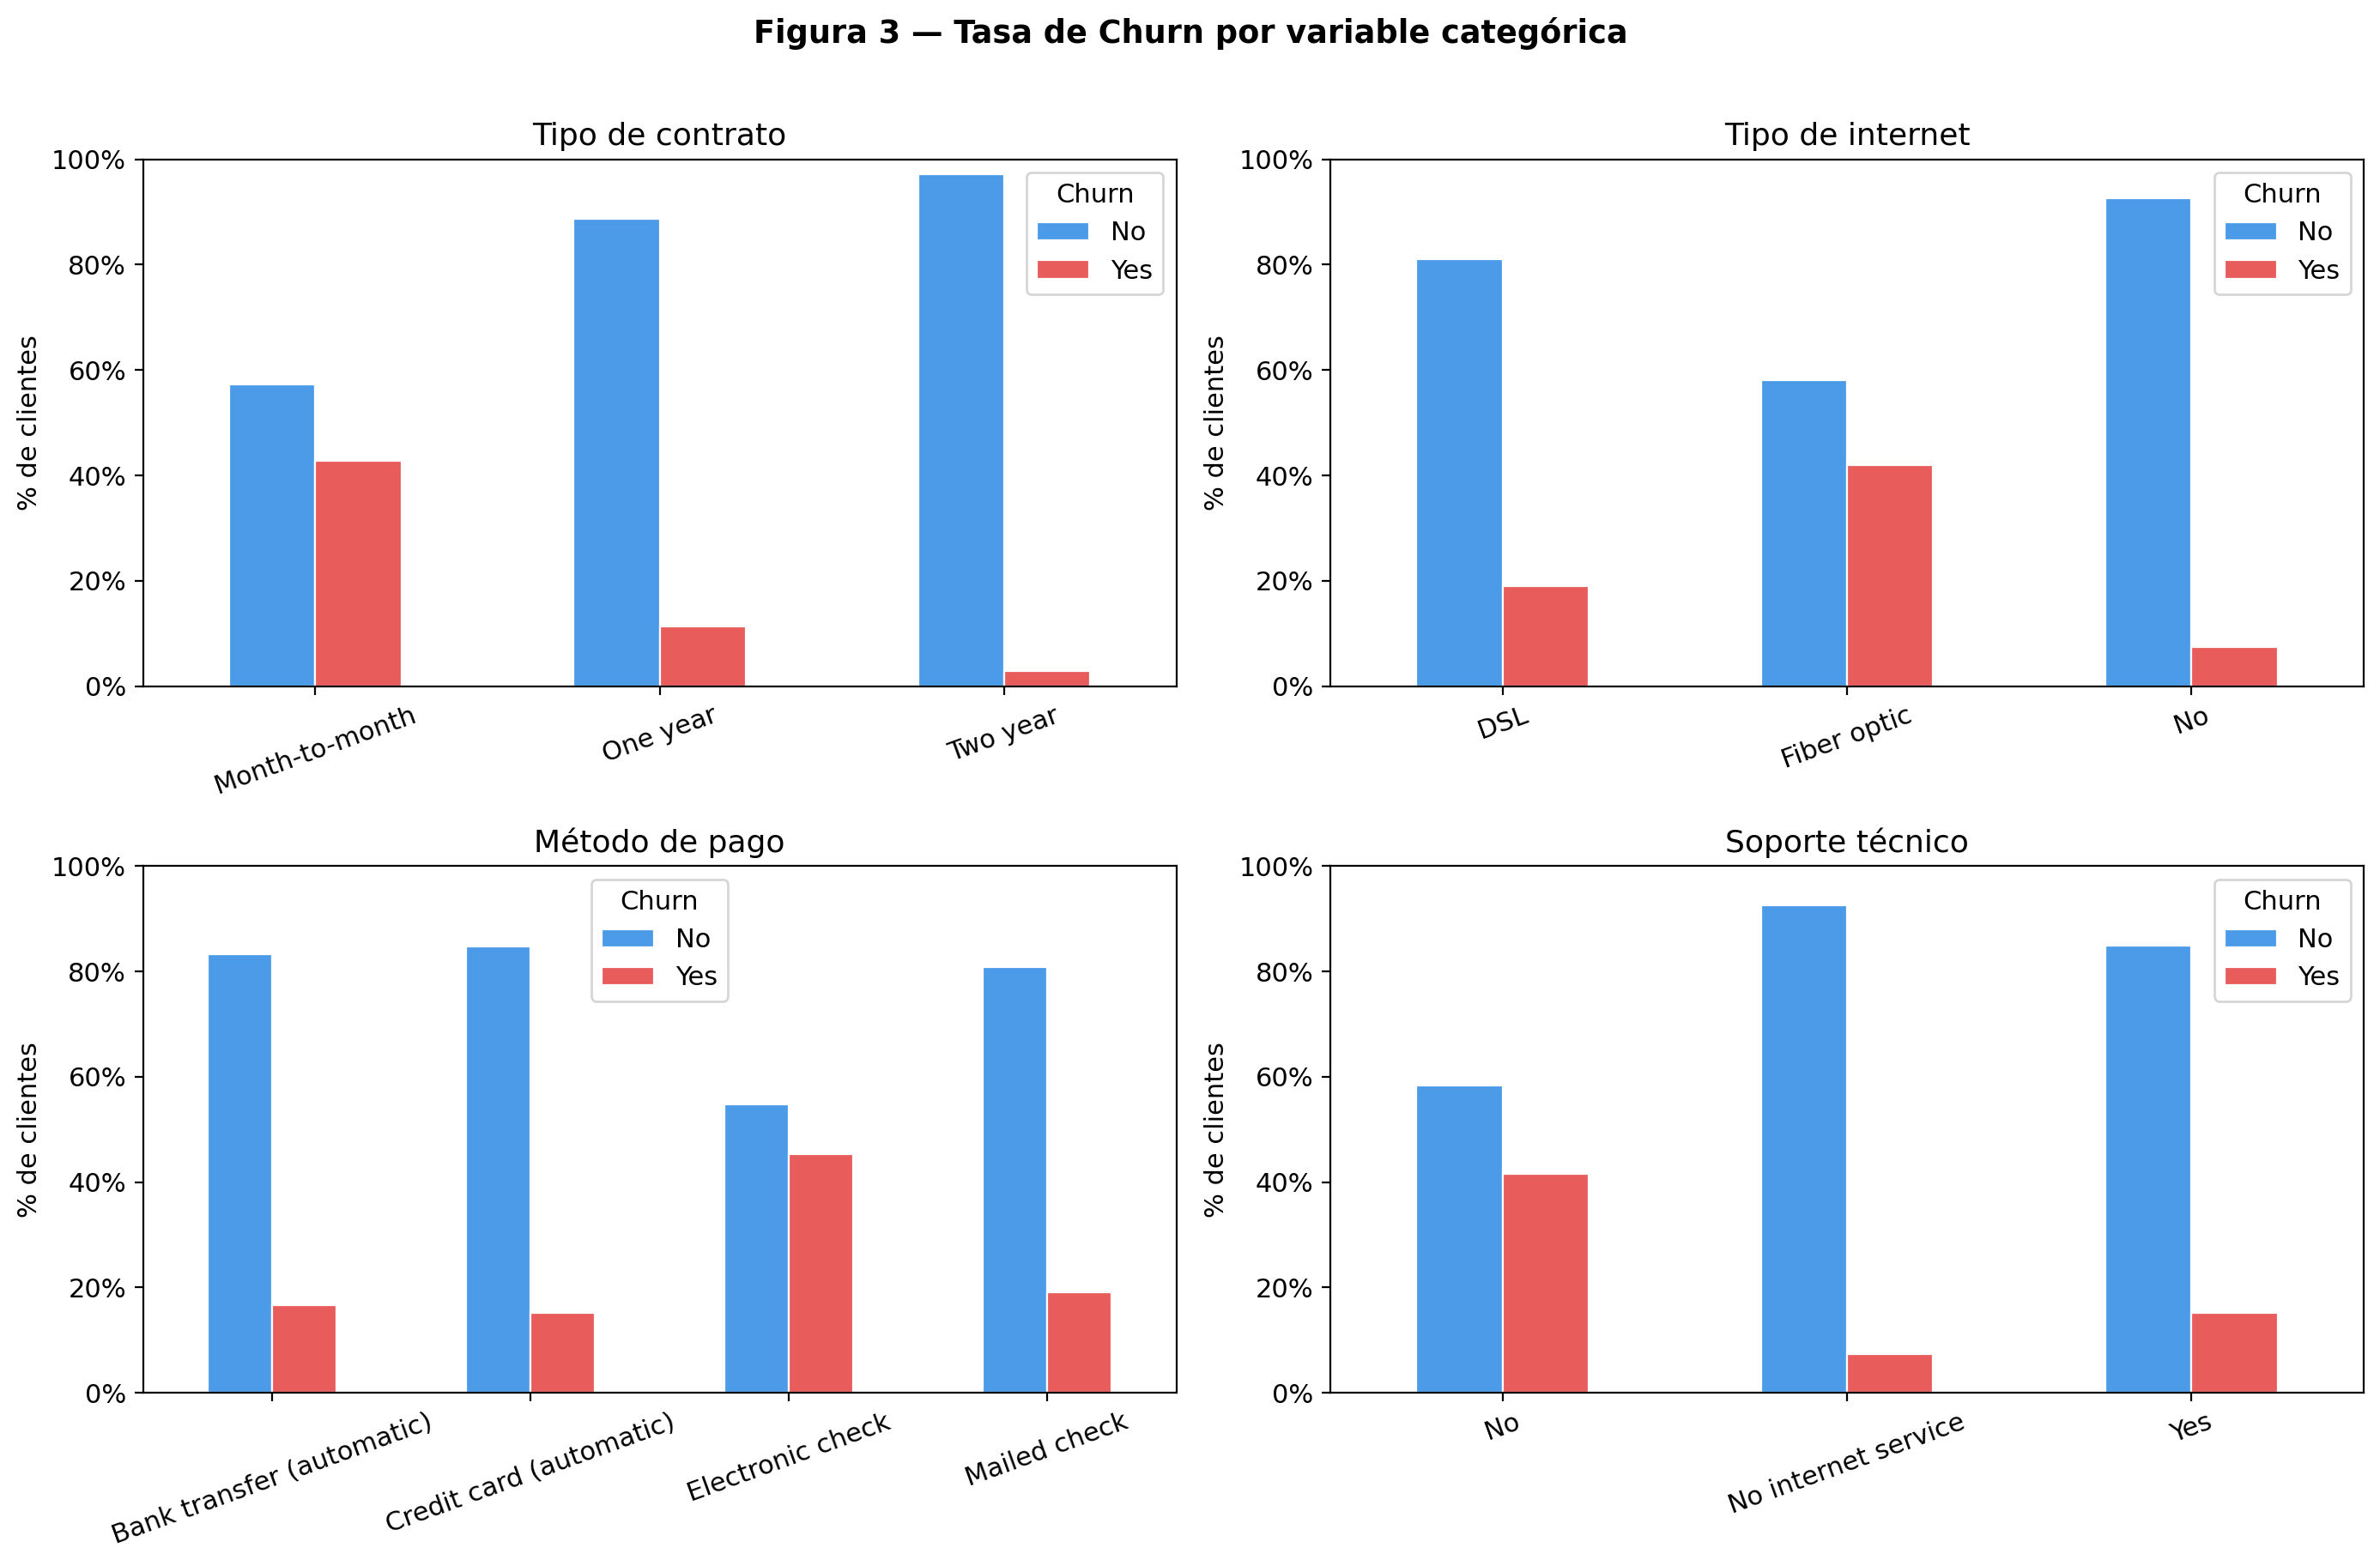

Clientes con contrato mes a mes: 42.7% tasa de churn
Decisión: la variable Contract será una de las más importantes en el modelo.


In [9]:
cat_vars = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']
titles   = ['Tipo de contrato', 'Tipo de internet', 'Método de pago', 'Soporte técnico']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, var, title in zip(axes, cat_vars, titles):
    # Tabla cruzada normalizada para obtener porcentajes por categoría
    ct = pd.crosstab(df[var], df['Churn'], normalize='index') * 100
    ct.plot(
        kind='bar', ax=ax,
        color=[PALETTE['No'], PALETTE['Yes']],
        edgecolor='white', linewidth=0.8
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('% de clientes')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Churn', labels=['No', 'Yes'])
    ax.set_ylim(0, 100)

plt.suptitle('Figura 3 — Tasa de Churn por variable categórica', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig3_categorical_churn.png')
plt.show()

tasa = df[df['Contract'] == 'Month-to-month']['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f'Clientes con contrato mes a mes: {tasa:.1f}% tasa de churn')
print('Decisión: la variable Contract será una de las más importantes en el modelo.')

## Figura 4: Mapa de calor de correlaciones

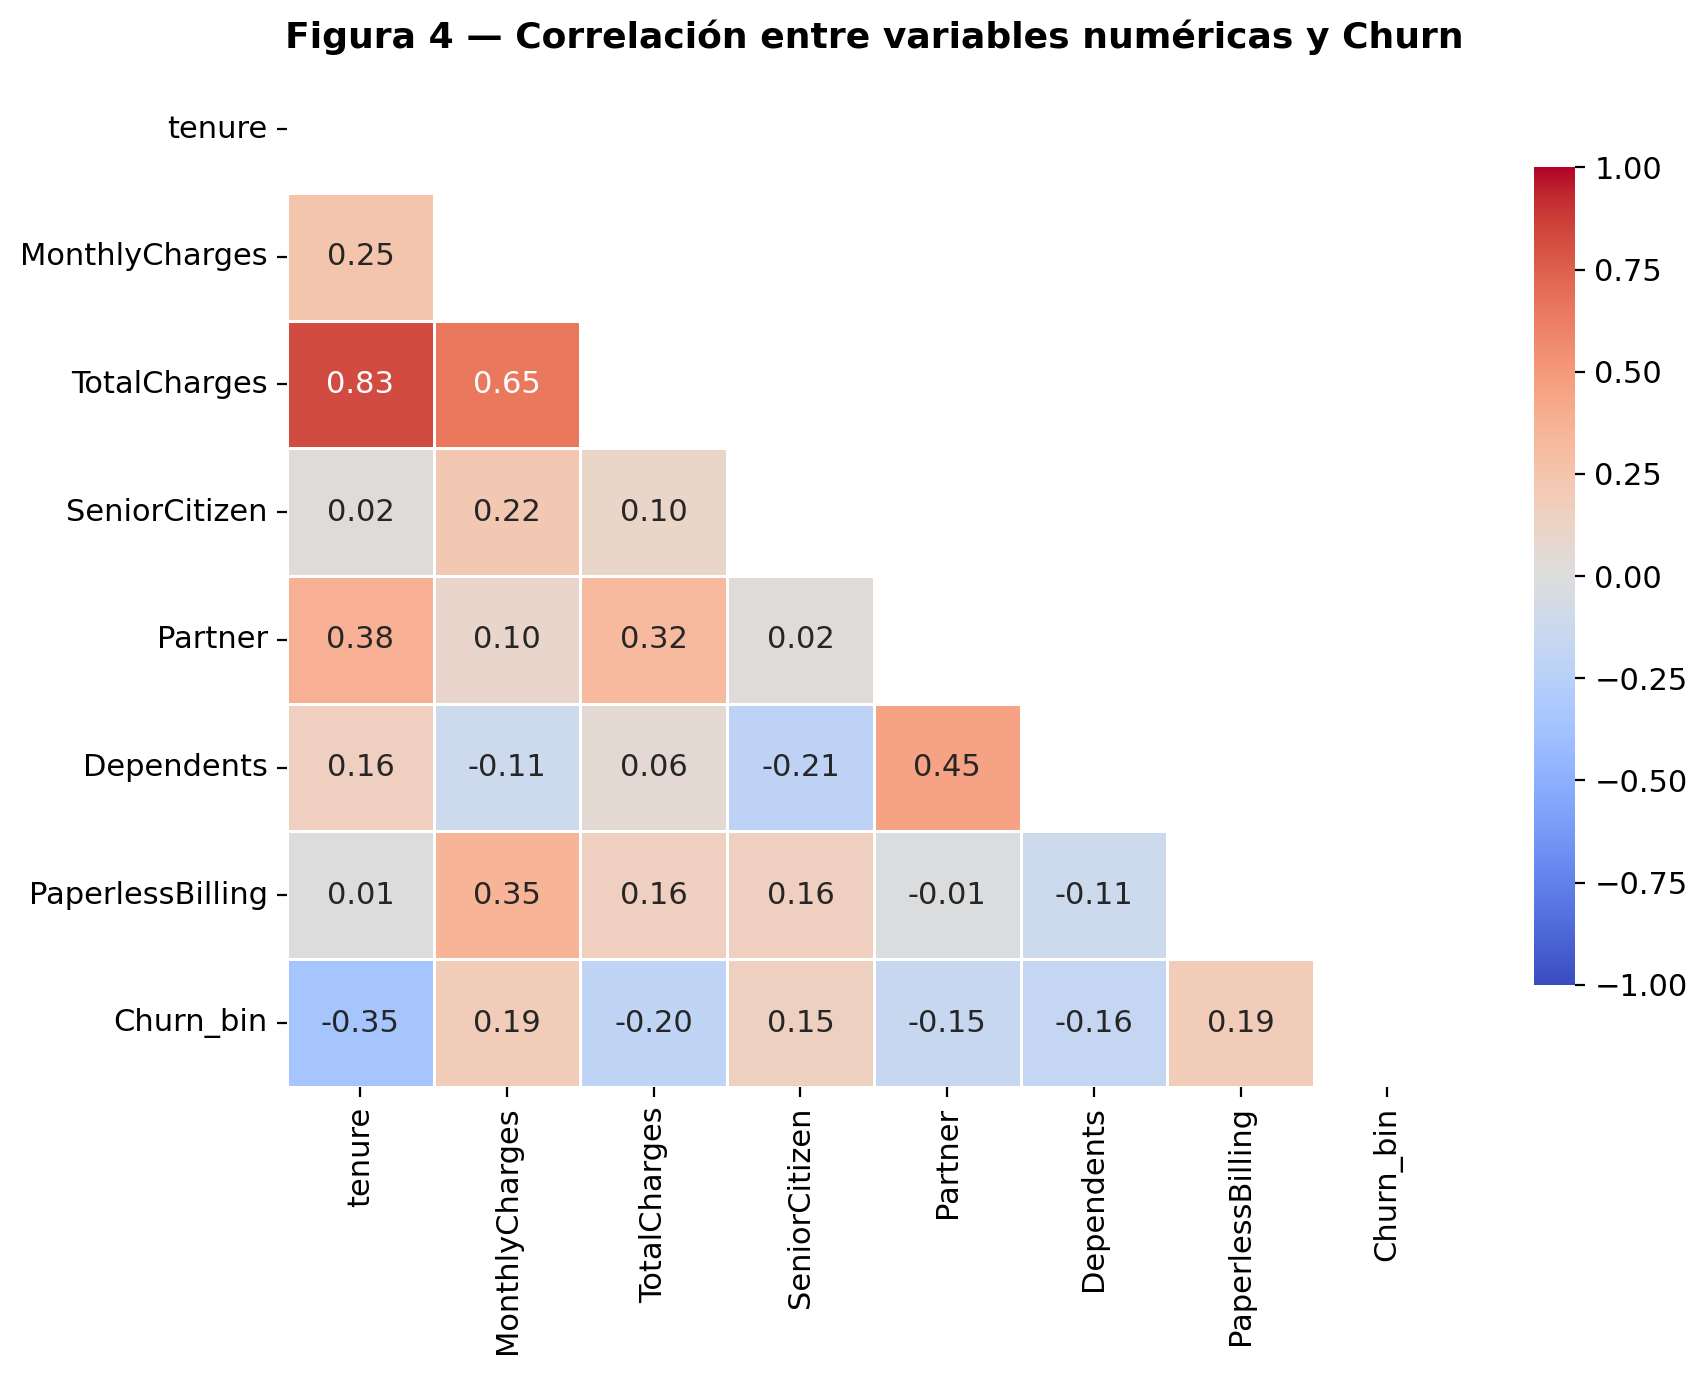

Correlación con Churn (de mayor a menor valor absoluto):
tenure             -0.352
TotalCharges       -0.198
MonthlyCharges      0.193
PaperlessBilling    0.192
Dependents         -0.164
SeniorCitizen       0.151
Partner            -0.150
Name: Churn_bin, dtype: float64


In [10]:
df_corr = df.copy()

# Codificación binaria para calcular correlaciones con variables categóricas simples
df_corr['Churn_bin'] = (df_corr['Churn'] == 'Yes').astype(int)
binary_cols = {'Partner': {'Yes': 1, 'No': 0},
               'Dependents': {'Yes': 1, 'No': 0},
               'PaperlessBilling': {'Yes': 1, 'No': 0}}
for col, mapping in binary_cols.items():
    df_corr[col] = df_corr[col].map(mapping)

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
             'SeniorCitizen', 'Partner', 'Dependents', 'PaperlessBilling', 'Churn_bin']

corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
# Máscara triangular para no mostrar la mitad duplicada
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax.set_title('Figura 4 — Correlación entre variables numéricas y Churn', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig4_correlation_heatmap.png')
plt.show()

print('Correlación con Churn (de mayor a menor valor absoluto):')
print(corr_matrix['Churn_bin'].drop('Churn_bin').sort_values(key=abs, ascending=False).round(3))

## Figura 5: Boxplots por grupo de Churn

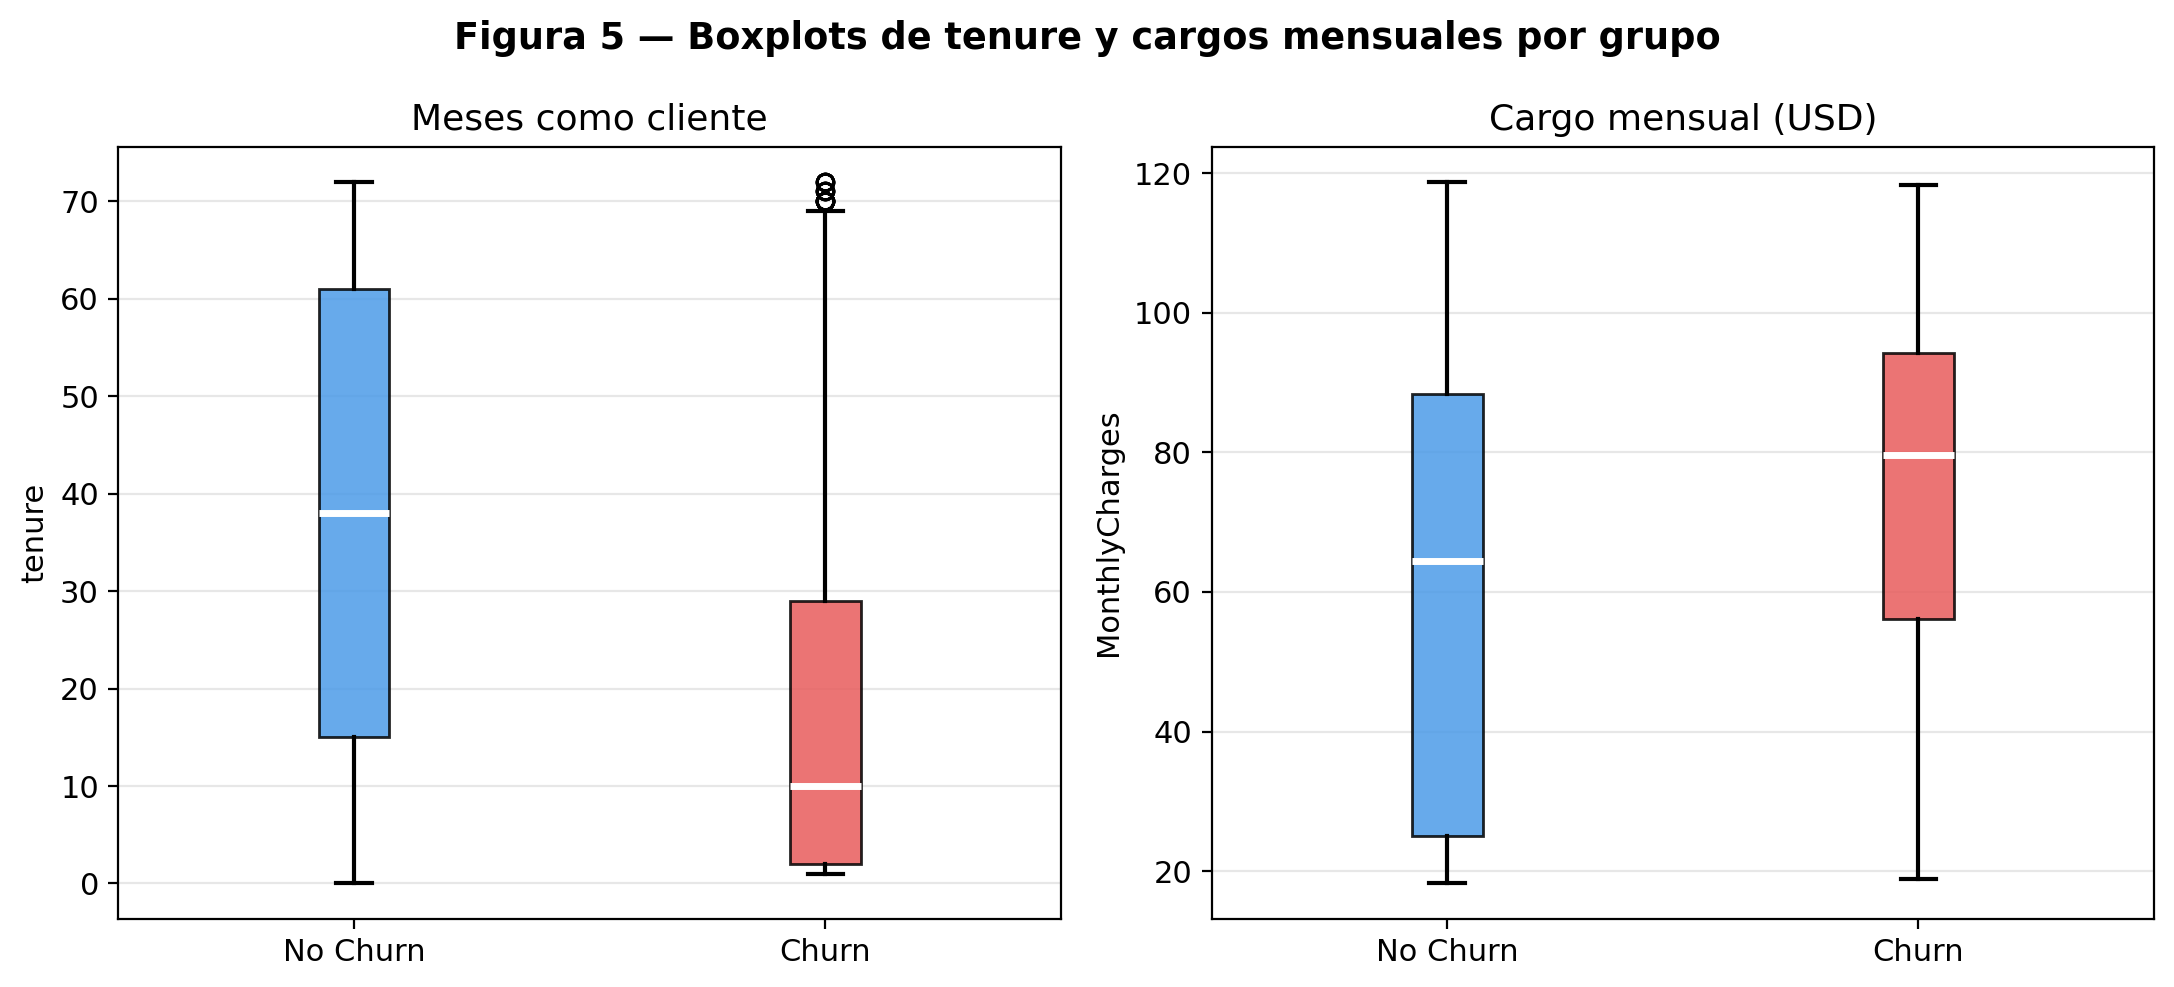

Mediana tenure     — No Churn: 38 meses | Churn: 10 meses
Mediana MonthlyCharges — No Churn: $64.43 | Churn: $79.65


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, var, label in zip(
    axes,
    ['tenure', 'MonthlyCharges'],
    ['Meses como cliente', 'Cargo mensual (USD)']
):
    data_no  = df[df['Churn'] == 'No'][var]
    data_yes = df[df['Churn'] == 'Yes'][var]

    bp = ax.boxplot(
        [data_no, data_yes],
        patch_artist=True,
        labels=['No Churn', 'Churn'],
        medianprops={'color': 'white', 'linewidth': 2.5},
        whiskerprops={'linewidth': 1.5},
        capprops={'linewidth': 1.5}
    )
    for patch, color in zip(bp['boxes'], [PALETTE['No'], PALETTE['Yes']]):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    ax.set_title(label)
    ax.set_ylabel(var)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Figura 5 — Boxplots de tenure y cargos mensuales por grupo', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig5_boxplots.png')
plt.show()

med_tenure_no  = df[df.Churn=='No']['tenure'].median()
med_tenure_yes = df[df.Churn=='Yes']['tenure'].median()
med_mc_no      = df[df.Churn=='No']['MonthlyCharges'].median()
med_mc_yes     = df[df.Churn=='Yes']['MonthlyCharges'].median()

print(f'Mediana tenure     — No Churn: {med_tenure_no:.0f} meses | Churn: {med_tenure_yes:.0f} meses')
print(f'Mediana MonthlyCharges — No Churn: ${med_mc_no:.2f} | Churn: ${med_mc_yes:.2f}')

## EDA Automático con sweetviz

In [12]:
import sweetviz as sv

# sweetviz compara directamente los dos grupos (Churn vs No Churn)
# generando un reporte HTML interactivo con distribuciones, correlaciones y alertas
reporte = sv.compare(
    [df[df['Churn'] == 'Yes'], 'Churn = Yes'],
    [df[df['Churn'] == 'No'],  'Churn = No']
)
reporte.show_html('../data/sweetviz_report.html')
print('Reporte guardado en data/sweetviz_report.html')
print('Abre ese archivo en el navegador para verlo.')

ModuleNotFoundError: No module named 'sweetviz'

## Resumen de hallazgos y decisiones para el modelo

In [ ]:
print("""
Hallazgos del EDA:

1. Desbalance de clases
   Aproximadamente el 26-27% de los clientes hacen Churn.
   Se usará class_weight='balanced' en el entrenamiento
   y AUC-ROC + F1 como métricas de evaluación.

2. Tenure (meses como cliente)
   Los clientes que abandonan llevan muchos menos meses en la empresa.
   Es la variable numérica con mayor poder discriminante.

3. Tipo de contrato
   Los contratos mes a mes concentran la mayor tasa de abandono (~43%).
   Los contratos anuales o bianuales bajan esa tasa a menos del 10%.

4. Cargos mensuales
   Los clientes que abandonan pagan más mensualmente.
   Esto está correlacionado con el uso de Fiber optic.

5. Valores nulos
   11 filas tenían TotalCharges nulo porque su tenure era 0.
   Se imputaron con 0 al no tener historial de facturación.

6. Variables más relevantes para el modelo
   tenure, Contract, MonthlyCharges, InternetService,
   TechSupport, PaymentMethod, PaperlessBilling.
""")

# Guardar dataset limpio para usar en el notebook de modelado
df.to_csv('../data/telco_clean.csv', index=False)
print('Dataset limpio guardado en: data/telco_clean.csv')
print('Figuras guardadas en: data/figures/')


Hallazgos del EDA:

1. Desbalance de clases
   Aproximadamente el 26-27% de los clientes hacen Churn.
   Se usará class_weight='balanced' en el entrenamiento
   y AUC-ROC + F1 como métricas de evaluación.

2. Tenure (meses como cliente)
   Los clientes que abandonan llevan muchos menos meses en la empresa.
   Es la variable numérica con mayor poder discriminante.

3. Tipo de contrato
   Los contratos mes a mes concentran la mayor tasa de abandono (~43%).
   Los contratos anuales o bianuales bajan esa tasa a menos del 10%.

4. Cargos mensuales
   Los clientes que abandonan pagan más mensualmente.
   Esto está correlacionado con el uso de Fiber optic.

5. Valores nulos
   11 filas tenían TotalCharges nulo porque su tenure era 0.
   Se imputaron con 0 al no tener historial de facturación.

6. Variables más relevantes para el modelo
   tenure, Contract, MonthlyCharges, InternetService,
   TechSupport, PaymentMethod, PaperlessBilling.

Dataset limpio guardado en: data/telco_clean.csv
Figur